In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
root = "/ptmp/rfechner/out/exp09"
paths = [
    os.path.join(root, p, 'val_jsonl') for p in os.listdir(root)
]
paths

['/ptmp/rfechner/out/exp09/qwen2.5_7b__grpo-s/val_jsonl',
 '/ptmp/rfechner/out/exp09/qwen2.5_7b__grpo/val_jsonl',
 '/ptmp/rfechner/out/exp09/qwen2.5_7b__kl-cov/val_jsonl',
 '/ptmp/rfechner/out/exp09/qwen2.5_7b__dapo/val_jsonl']

In [3]:
def gather_logprobs_with_percentile(path: str):
    checkpoint_results = []
    files = sorted(
        [x for x in os.listdir(path) if x.endswith("_precomp.jsonl")],
        key=lambda x: int(x.split("_")[0])
    )
    files = [files[0], files[-1]]
    print("Processing only first and last.")

    suffix_ks = np.arange(1, 10) / 10
    prefix_ks = np.arange(1, 10) / 10
    percentiles_p = np.array([0.01, 0.05, 0.1, 0.2])

    for file in files:
        filepath = os.path.join(path, file)
        print(f"Processing file: {filepath}")
        chunks = pd.read_json(filepath, lines=True, chunksize=10000)

        dfs = []
        for counter, chunk in enumerate(chunks):
            if counter % 10 == 0:
                print(f'File: {file}, Chunk: {counter}')

            # Convert list-of-logprobs to fixed object array for faster slicing
            logs = chunk["logprobs"].to_numpy()
            logs = np.array([np.asarray(row, dtype=float) for row in logs], dtype=object)

            # Preallocate result columns
            res = {
                "input_hash": chunk["input"].apply(hash).to_numpy(),
                "logprobs": np.array([x.mean() for x in logs]),
                "entropy": np.array([np.mean(e) for e in chunk["entropy"]]),
                "score": chunk["score"].to_numpy(),
                "checkpoint_global_step": chunk["checkpoint_global_step"].to_numpy(),
                "data_global_step": chunk["data_global_step"].to_numpy(),
            }

            # ----- Compute suffix & prefix logprob means (vectorized loop) -----
            for k in suffix_ks:
                name = f"suffix_{k}_logprobs"
                res[name] = np.array([
                    row[int(k * len(row)):].mean() if int(k * len(row)) > 0 else np.nan
                    for row in logs
                ])

            for k in prefix_ks:
                name = f"prefix_{k}_logprobs"
                res[name] = np.array([
                    row[:int(k * len(row))].mean() if int(k * len(row)) > 0 else np.nan
                    for row in logs
                ])

            # ----- Compute percentile means -----
            # Sorting each row once is dramatically faster
            sorted_logs = [np.sort(row) for row in logs]

            for p in percentiles_p:
                name = f"logprob_percentile_{p}"
                res[name] = np.array([
                    row[: int(p * len(row))].mean() if int(p * len(row)) > 0 else np.nan
                    for row in sorted_logs
                ])

            dfs.append(pd.DataFrame(res))

        checkpoint_results.append(pd.concat(dfs, ignore_index=True))

    return checkpoint_results


In [4]:
RELOAD = False
import pickle
root="/u/rfechner/verl/workspace/plots/.tmpfiles"
os.makedirs(root, exist_ok=True)

if RELOAD:
    mapper = {}
    for path in paths:
        outs = gather_logprobs_with_percentile(path)
        mapper[path] = outs

    with open(os.path.join(root, 'exp09_gather_logprobs_with_percentile_2.pickle'), 'wb') as file:
        pickle.dump(obj=mapper, file=file)
else:
    with open(os.path.join(root, 'exp09_gather_logprobs_with_percentile_2.pickle'), 'rb') as file:
        mapper = pickle.load(file=file)

In [5]:
import matplotlib.pyplot as plt
plotdir = os.path.join(root, 'plots')
os.makedirs(plotdir, exist_ok=True)


# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

VAL_FREQ = 5
K_VALUES = np.arange(1, 10) / 10

def plot_prefix_suffix(experiment_name: str, outs: list[pd.DataFrame], plotname_prefix=None) -> None:
    first, last = outs

    cmap = plt.get_cmap('viridis', len(K_VALUES))

    # ---------- compute stats ----------
    def compute_stats(df, colname):
        values, stds = [], []
        groups = df.groupby("data_global_step", sort=True)
        for _, group in groups:
            arr = group[colname].to_numpy()
            values.append(np.nanmean(arr))
            stds.append(np.nanstd(arr))
        return values, stds

    # ---------- FIGURE ----------
    fig, (ax1, ax2) = plt.subplots(
        nrows=1, ncols=2, sharey=False, figsize=(12, 4)
    )

    # ==========================================================
    # ===================== SUFFIX PLOT =========================
    # ==========================================================

    for i, k in enumerate(K_VALUES):
        col = f"suffix_{k}_logprobs"
        first_vals, _ = compute_stats(first, col)
        last_vals, _  = compute_stats(last, col)

        xs_first = np.arange(0, len(first_vals) * VAL_FREQ, VAL_FREQ)
        xs_last  = np.arange(0, len(last_vals)  * VAL_FREQ, VAL_FREQ)

        color = cmap(i)
        ax1.errorbar(xs_first, first_vals, label=fr"$k={k},\,\theta_{{base}}$", 
                     color=color, linestyle="--")
        ax1.errorbar(xs_last, last_vals, label=fr"$k={k},\,\theta_{{RL}}$", 
                     color=color)

    ax1.set_ylabel(r"$p(x[k \cdot N:] \mid \theta_j)$", fontsize=12)
    ax1.set_xlabel(r"$x[k \cdot N:]$ \textbf{ source checkpoint training step}", fontsize=11)
    ax1.set_title(r"\textbf{Suffix likelihoods } $p(x[k \cdot N:] \mid \theta_j)$", fontsize=13)

    # ==========================================================
    # ===================== PREFIX PLOT =========================
    # ==========================================================

    for i, k in enumerate(K_VALUES):
        col = f"prefix_{k}_logprobs"
        first_vals, _ = compute_stats(first, col)
        last_vals, _  = compute_stats(last, col)

        xs_first = np.arange(0, len(first_vals) * VAL_FREQ, VAL_FREQ)
        xs_last  = np.arange(0, len(last_vals)  * VAL_FREQ, VAL_FREQ)

        color = cmap(i)
        ax2.errorbar(xs_first, first_vals, label=fr"$k={k},\,\theta_{{base}}$", 
                     color=color, linestyle="--")
        ax2.errorbar(xs_last, last_vals, label=fr"$k={k},\,\theta_{{RL}}$", 
                     color=color)

    ax2.set_ylabel(r"$p(x[:k\cdot N] \mid \theta_j)$", fontsize=12)
    ax2.set_xlabel(r"$x[:k\cdot N]$ \textbf{ source checkpoint training step}", fontsize=11)
    ax2.set_title(r"\textbf{Prefix likelihoods } $p(x[:k\cdot N] \mid \theta_j)$", fontsize=13)

    # ---------- Title ----------
    model, method = experiment_name.split("__")
    plt.suptitle(
        rf"Log-likelihoods of subsequences, Normalized by Sequence Length; \quad \textbf{{Model:}} {model} \qquad \textbf{{Method:}} {method}",
        fontsize=14
    )

    # ---------- Legend ----------
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left", fontsize=9)

    plt.savefig(os.path.join(plotdir, f"{plotname_prefix + '-' if plotname_prefix else ''}{experiment_name}_prefix_suffix_plot.pdf"), dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

In [6]:
mapper.keys()

dict_keys(['/ptmp/rfechner/out/exp09/qwen2.5_7b__grpo-s/val_jsonl', '/ptmp/rfechner/out/exp09/qwen2.5_7b__grpo/val_jsonl', '/ptmp/rfechner/out/exp09/qwen2.5_7b__kl-cov/val_jsonl', '/ptmp/rfechner/out/exp09/qwen2.5_7b__dapo/val_jsonl'])

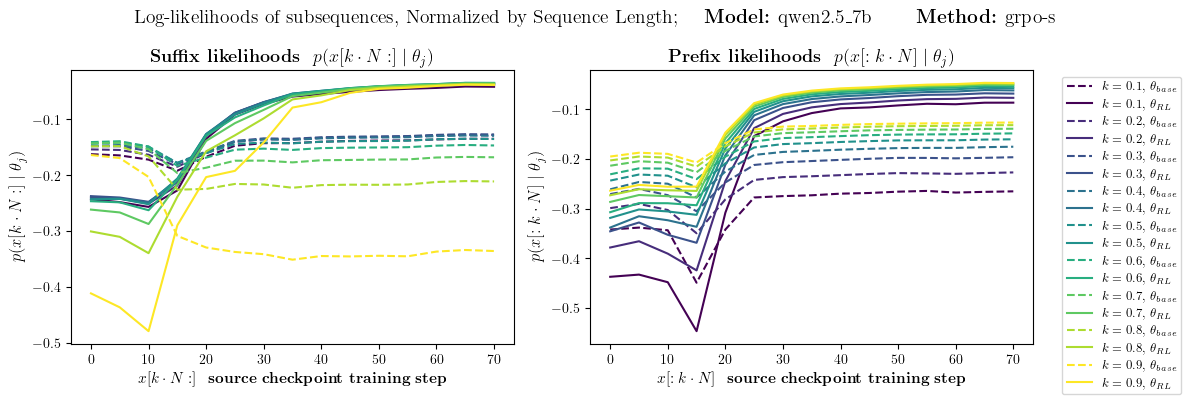

In [7]:
name = '/ptmp/rfechner/out/exp09/qwen2.5_7b__grpo-s/val_jsonl'
experiment_name = "qwen2.5_7b__grpo-s"
plot_prefix_suffix(experiment_name, mapper[name], plotname_prefix='seqlen_normalized_k-')

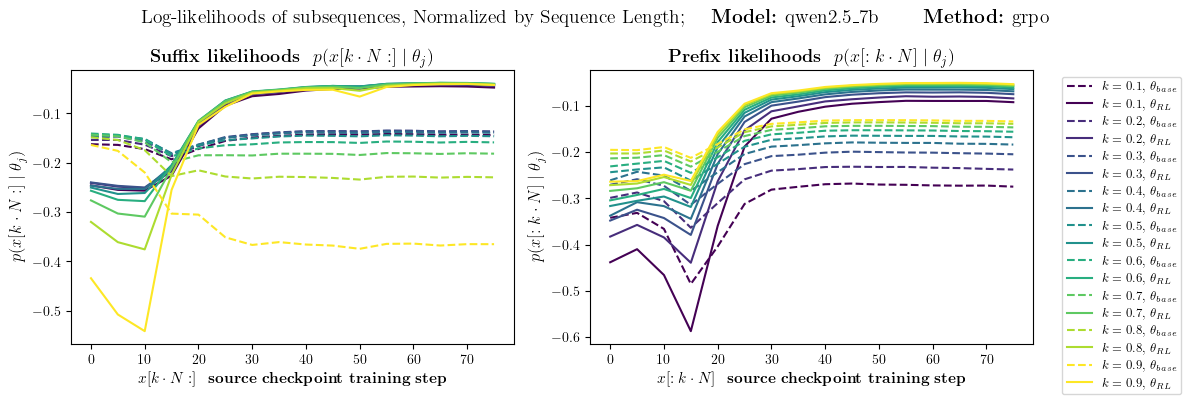

In [8]:
name = '/ptmp/rfechner/out/exp09/qwen2.5_7b__grpo/val_jsonl'
experiment_name = "qwen2.5_7b__grpo"
plot_prefix_suffix(experiment_name, mapper[name], plotname_prefix='seqlen_normalized_k-')

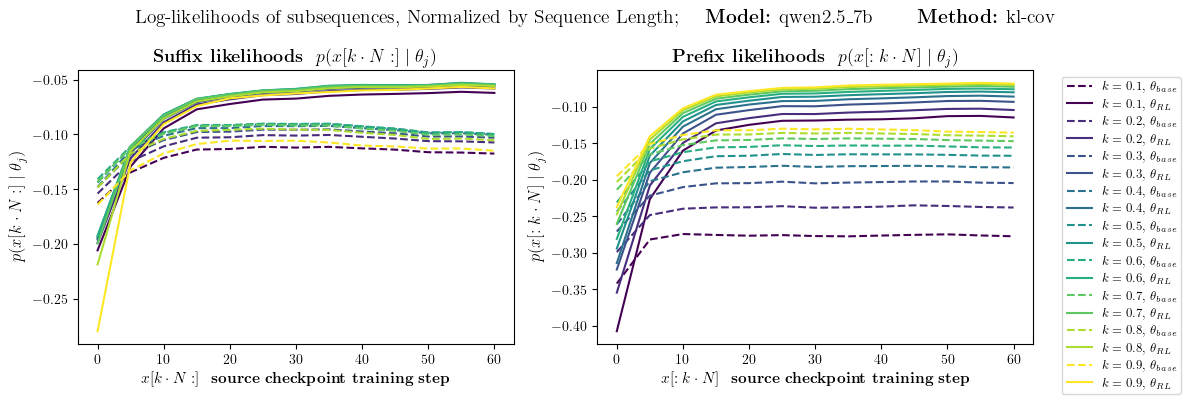

In [9]:
name = '/ptmp/rfechner/out/exp09/qwen2.5_7b__kl-cov/val_jsonl'
experiment_name = "qwen2.5_7b__kl-cov"
plot_prefix_suffix(experiment_name, mapper[name], plotname_prefix='seqlen_normalized_k-')

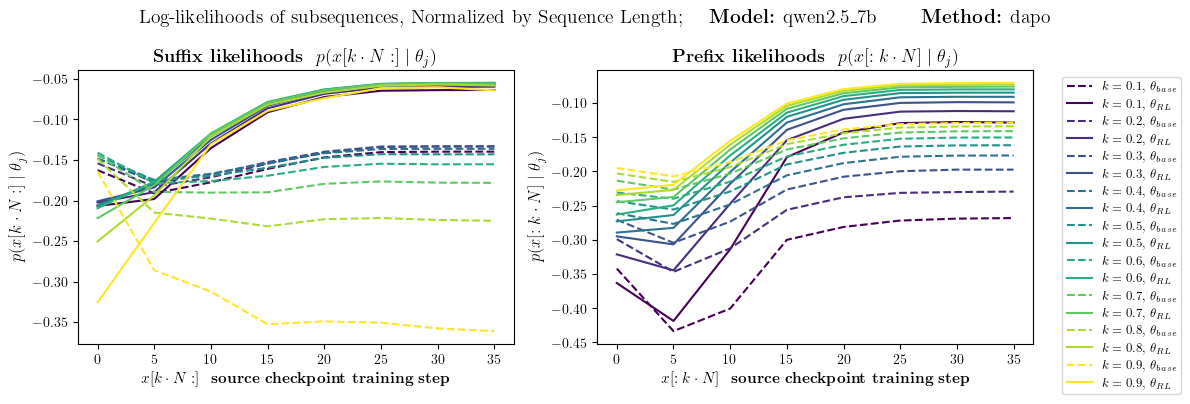

In [10]:
name = '/ptmp/rfechner/out/exp09/qwen2.5_7b__dapo/val_jsonl'
experiment_name = "qwen2.5_7b__dapo"
plot_prefix_suffix(experiment_name, mapper[name], plotname_prefix='seqlen_normalized_k-')

### Vizualizing p-percentile means of log-likelihoods

In [11]:
P_VALUES = np.array([0.01, 0.05, 0.1, 0.2])
def plot_percentiles(experiment_name: str, outs: list[pd.DataFrame], plotname_prefix=None) -> None:
    first, last = outs

    cmap = plt.get_cmap('viridis', len(P_VALUES))

    # ---------- compute stats ----------
    def compute_stats(df, colname):
        values, stds = [], []
        groups = df.groupby("data_global_step", sort=True)
        for _, group in groups:
            arr = group[colname].to_numpy()
            values.append(np.nanmean(arr))
            stds.append(np.nanstd(arr))
        return values, stds

    # ---------- FIGURE ----------
    fig, ax1 = plt.subplots(
        nrows=1, ncols=1, sharey=False, figsize=(6, 4)
    )

    for i, p in enumerate(P_VALUES):
        col = f"logprob_percentile_{p}"
        first_vals, _ = compute_stats(first, col)
        last_vals, _  = compute_stats(last, col)

        xs_first = np.arange(0, len(first_vals) * VAL_FREQ, VAL_FREQ)
        xs_last  = np.arange(0, len(last_vals)  * VAL_FREQ, VAL_FREQ)

        color = cmap(i)
        ax1.errorbar(xs_first, first_vals, label=fr"$p={p},\,\theta_{{base}}$", 
                     color=color, linestyle="--")
        ax1.errorbar(xs_last, last_vals, label=fr"$p={p},\,\theta_{{RL}}$", 
                     color=color)

    ax1.set_ylabel(r"\textbf{Mean Logprob}", fontsize=12)
    ax1.set_xlabel(r"\textbf{Source checkpoint training step}", fontsize=12)
    
    # ---------- Title ----------
    model, method = experiment_name.split("__")
    plt.suptitle(
        rf"Log-likelihoods of p-percentiles; \quad \textbf{{Model:}} {model} \qquad \textbf{{Method:}} {method}",
        fontsize=14
    )

    # ---------- Legend ----------
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left", fontsize=9)

    plt.savefig(os.path.join(plotdir, f"{plotname_prefix + '-' if plotname_prefix else ''}{experiment_name}_percentiles.pdf"), dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

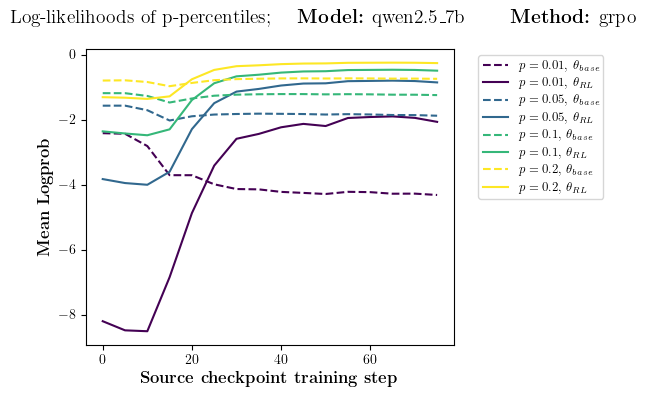

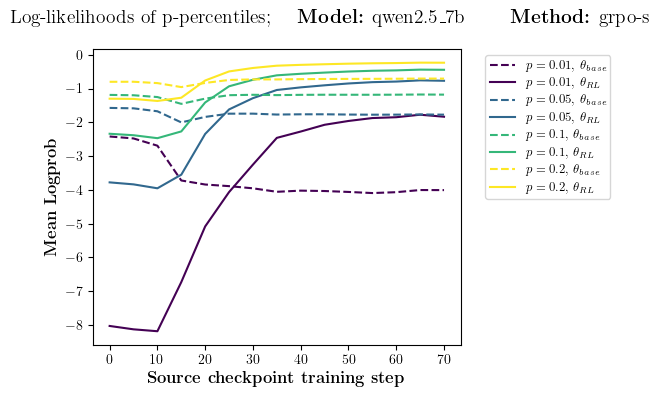

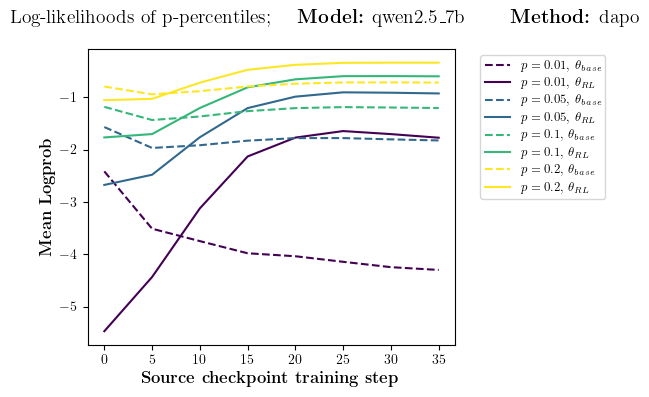

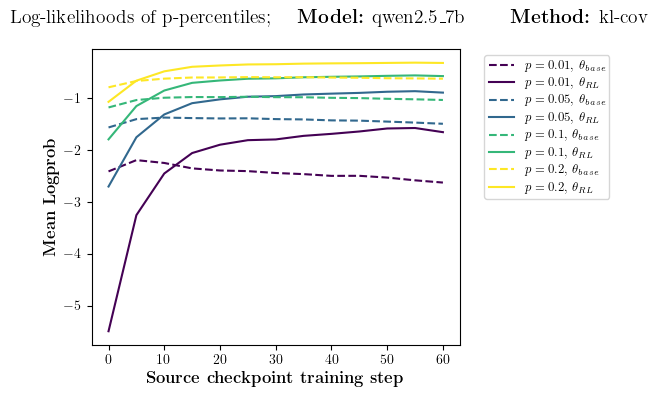

In [13]:
for method in ['grpo', 'grpo-s', 'dapo', 'kl-cov']:
    name = f'/ptmp/rfechner/out/exp09/qwen2.5_7b__{method}/val_jsonl'
    experiment_name = f"qwen2.5_7b__{method}"
    plot_percentiles(experiment_name, mapper[name])